# Relatório Executivo: Bares, Restaurantes e Alimentação Fora do Lar
**Fonte:** Dados Públicos de CNPJ da Receita Federal (Brasil todo, competência 2026-08).  
**Recorte:** 6 CNAEs do setor (5611-2/01, 5611-2/03, 5611-2/04, 5611-2/05, 5620-1/04 e 4721-1/02).

---

### Resumo Executivo das Respostas

| Pergunta | Resposta Oficial | Destaque |
|---|---|---|
| **1. Empresas ativas hoje** | **1.511.132 empresas** | 97,6% são matrizes (negócio de ponto único) |
| **2. Aberturas nos últimos 5 anos** | **1.507.905 empresas abertas** entre 2021 e 2025 | Pico em 2021 (356.849) e 315.376 em 2025 |
| **3. Porte predominante** | **MEI lidera com 63,1%** | Microempresa (ME) vem em seguida com 32,2% |


## 1. Conexão com os Dados Tratados
Carregamos os dados analíticos consolidados via DuckDB:

In [1]:
from pathlib import Path
import duckdb
import pandas as pd

# Localiza os dados tratados
RAIZ = Path.cwd() if (Path.cwd() / "dados").exists() else Path.cwd().parent
con = duckdb.connect()

# Visão analítica principal
con.execute(f"CREATE VIEW base AS SELECT * FROM read_parquet('{RAIZ}/dados/tratados/base_afl.parquet')")

# Total geral de registros no setor
total = con.sql('''
    SELECT count(*) AS total_estabelecimentos, 
           count(DISTINCT cnpj_basico) AS total_empresas 
    FROM base
''').df()
total

,total_estabelecimentos,total_empresas
0,5224132,5129800


---
## 2. Pergunta 1: Quantas empresas do setor estão ativas hoje?

No cadastro da Receita, cada ponto físico é um **estabelecimento**. Empresas distintas são identificadas pelo **CNPJ básico** (8 primeiros dígitos).

In [2]:
# 1. Total de empresas ativas vs. estabelecimentos
ativas = con.sql('''
    SELECT 
        count(DISTINCT cnpj_basico) AS empresas_ativas,
        count(*) AS estabelecimentos_ativos
    FROM base 
    WHERE situacao = 'Ativa'
''').df()
ativas

,empresas_ativas,estabelecimentos_ativos
0,1511132,1543267


Text(0, 0.5, '')

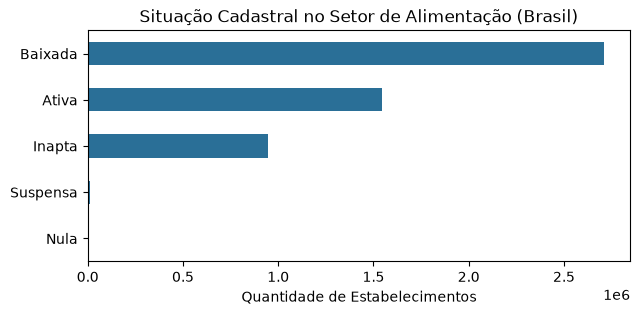

In [3]:
# 2. Distribuição da situação cadastral do setor
situacao = con.sql('''
    SELECT situacao, count(*) AS total
    FROM base 
    GROUP BY 1 
    ORDER BY total ASC
''').df()

# Gráfico direto via Pandas
ax = situacao.plot.barh(x='situacao', y='total', legend=False, color='#2a6f97', figsize=(7, 3))
ax.set_title("Situação Cadastral no Setor de Alimentação (Brasil)")
ax.set_xlabel("Quantidade de Estabelecimentos")
ax.set_ylabel("")

* **Insight:** Mais de 2,7 milhões de CNPJs do setor já foram baixados ao longo da história. O setor tem alta rotatividade de abertura e fechamento.

---
## 3. Pergunta 2: Como evoluiu a abertura de empresas nos últimos 5 anos?

Consideramos cinco anos completos, de **2021 a 2025**, usando a data de início de atividade de cada estabelecimento.


Text(0, 0.5, 'Novas empresas')

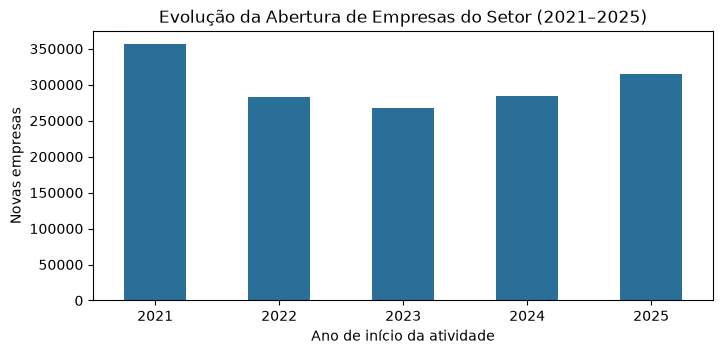

In [4]:
# Aberturas anuais do período pedido: 2021 a 2025
aberturas = con.sql('''
    SELECT ano_inicio AS ano, count(*) AS novas_aberturas
    FROM base
    WHERE ano_inicio BETWEEN 2021 AND 2025
    GROUP BY 1
    ORDER BY 1
''').df()

ax = aberturas.plot.bar(
    x='ano', y='novas_aberturas', legend=False,
    color='#2a6f97', rot=0, figsize=(8, 3.5)
)
ax.set_title("Evolução da Abertura de Empresas do Setor (2021–2025)")
ax.set_xlabel("Ano de início da atividade")
ax.set_ylabel("Novas empresas")


In [5]:
# Tabela com percentual de participação do setor no total de empresas do Brasil
participacao = con.sql(f'''
    SELECT 
        s.ano,
        s.aberturas AS aberturas_setor,
        p.aberturas AS aberturas_brasil,
        round(100.0 * s.aberturas / p.aberturas, 1) AS share_pct
    FROM (SELECT ano_inicio AS ano, count(*) AS aberturas FROM base GROUP BY 1) s
    JOIN read_csv('{RAIZ}/dados/tratados/aberturas_pais_por_ano.csv') p ON s.ano = p.ano
    WHERE s.ano BETWEEN 2021 AND 2025
    ORDER BY s.ano
''').df()
participacao

,ano,aberturas_setor,aberturas_brasil,share_pct
0,2021,356849,4139548,8.6
1,2022,282586,3977554,7.1
2,2023,268190,3984872,6.7
3,2024,284904,4844030,5.9
4,2025,315376,5194734,6.1


* **Insight:** Entre 2021 e 2025, o setor registrou **1.507.905 aberturas**. O maior valor foi em 2021 (356.849); após o menor ponto em 2023 (268.190), as aberturas voltaram a crescer em 2024 e 2025 (315.376).

---
## 4. Pergunta 3: Qual o porte predominante?

O campo `porte` padrão da Receita omite o MEI (ele só classifica ME, EPP e Demais). Por isso, cruzamos com a base oficial do **Simples Nacional** para extrair o MEI com exatidão:


Text(0, 0.5, '')

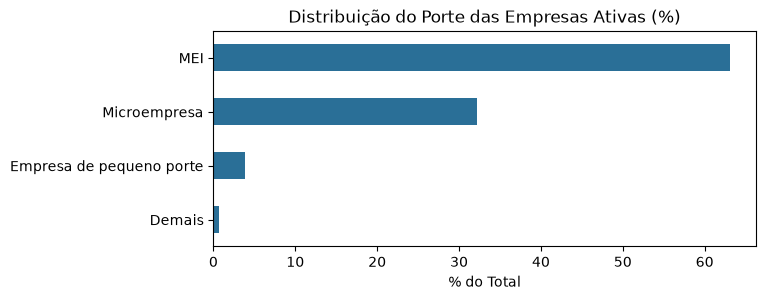

In [6]:
porte = con.sql('''
    SELECT 
        CASE WHEN mei = 'MEI' THEN 'MEI' ELSE porte END AS porte_real,
        count(DISTINCT cnpj_basico) AS total_empresas
    FROM base
    WHERE situacao = 'Ativa'
    GROUP BY 1
    ORDER BY total_empresas ASC
''').df()

porte['percentual'] = (porte['total_empresas'] / porte['total_empresas'].sum() * 100).round(1)

# Gráfico de barras simples
ax = porte.plot.barh(x='porte_real', y='percentual', legend=False, color='#2a6f97', figsize=(7, 2.8))
ax.set_title("Distribuição do Porte das Empresas Ativas (%)")
ax.set_xlabel("% do Total")
ax.set_ylabel("")

In [7]:
porte.sort_values(by='total_empresas', ascending=False)

,porte_real,total_empresas,percentual
3,MEI,953769,63.1
2,Microempresa,486715,32.2
1,Empresa de pequeno porte,59403,3.9
0,Demais,11245,0.7


* **Insight:** O setor é composto massivamente por pequenos negócios: **63,1% são MEIs** e **32,2% são Microempresas**. Apenas 4,6% são empresas de porte maior.

---
## 5. Destaques Regionais e Segmentos

Text(0.5, 0, 'UF')

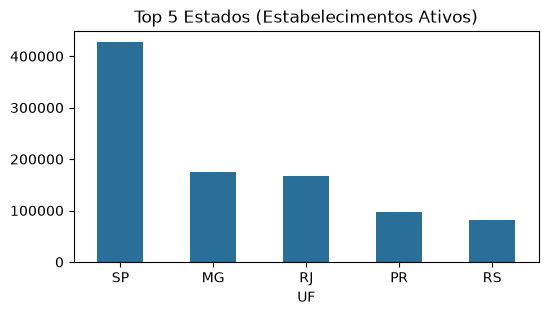

In [8]:
# Top 5 Estados com mais estabelecimentos ativos
top_ufs = con.sql('''
    SELECT uf, count(*) AS total_estabelecimentos
    FROM base
    WHERE situacao = 'Ativa'
    GROUP BY 1
    ORDER BY total_estabelecimentos DESC
    LIMIT 5
''').df()

ax = top_ufs.plot.bar(x='uf', y='total_estabelecimentos', legend=False, color='#2a6f97', rot=0, figsize=(6, 3))
ax.set_title("Top 5 Estados (Estabelecimentos Ativos)")
ax.set_xlabel("UF")

Text(0, 0.5, '')

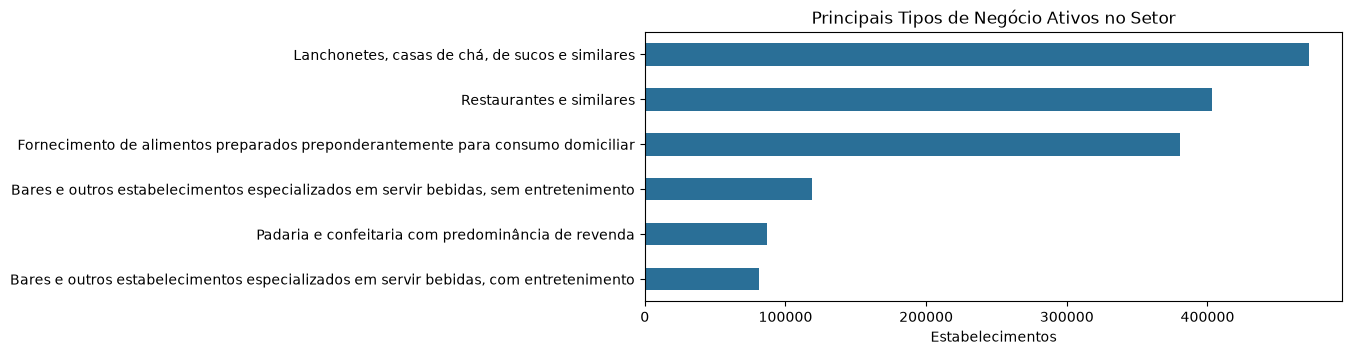

In [9]:
# Segmentos com maior volume
tipos = con.sql('''
    SELECT 
        cnae_descricao AS atividade,
        count(*) AS ativos
    FROM base 
    WHERE situacao = 'Ativa'
    GROUP BY 1
    ORDER BY ativos ASC
''').df()

ax = tipos.plot.barh(x='atividade', y='ativos', legend=False, color='#2a6f97', figsize=(9, 3.5))
ax.set_title("Principais Tipos de Negócio Ativos no Setor")
ax.set_xlabel("Estabelecimentos")
ax.set_ylabel("")

---
## Conclusão Sintética

1. **Setor de pequenos negócios:** há 1,5 milhão de empresas ativas; 97,6% têm somente matriz e mais de 95% são MEI ou Microempresa.
2. **Abertura consistente:** nos cinco anos completos analisados, foram 1.507.905 empresas abertas. O pico foi em 2021 e 2025 encerrou o período com 315.376 novas empresas.
3. **São Paulo lidera:** concentra quase 28% dos estabelecimentos ativos do país.
